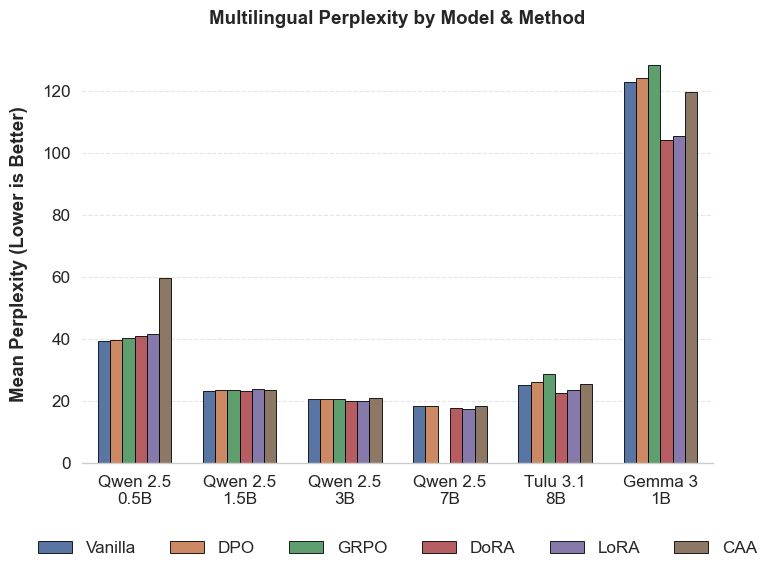

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("notebook_plots", exist_ok=True)

sns.set_context("paper", font_scale=1.4) 
sns.set_style("whitegrid")

# prep data
df = pd.read_csv("res.csv")
df = df[df['Metrics'] == 'ppl'].copy()

model_map = {
    "Qwen/Qwen2.5-0.5B-Instruct": "Qwen 2.5\n0.5B",
    "Qwen/Qwen2.5-1.5B-Instruct": "Qwen 2.5\n1.5B",
    "Qwen/Qwen2.5-3B-Instruct": "Qwen 2.5\n3B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen 2.5\n7B",
    "allenai/Llama-3.1-Tulu-3.1-8B": "Tulu 3.1\n8B",
    "google/gemma-3-1b-it": "Gemma 3\n1B",
}

df['Model'] = df['Model'].map(model_map)
df['Language'] = df['Dataset'].str.replace('PPL ', '')

model_order = [
    "Qwen 2.5\n0.5B",
    "Qwen 2.5\n1.5B",
    "Qwen 2.5\n3B",
    "Qwen 2.5\n7B",
    "Tulu 3.1\n8B",
    "Gemma 3\n1B",
]

methods_to_plot = ['Vanilla', 'DPO', 'GRPO', 'DoRA', 'LoRA', 'CAA']

bar_data = df.melt(
    id_vars=['Model'], 
    value_vars=methods_to_plot, 
    var_name='Method', 
    value_name='PPL'
)

# aggregate mean PPL across languages
bar_data_agg = bar_data.groupby(['Model', 'Method'])['PPL'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
classic_palette = sns.color_palette(n_colors=len(methods_to_plot))

sns.barplot(
    data=bar_data_agg, 
    x='Model', 
    y='PPL', 
    hue='Method', 
    order=model_order,
    hue_order=methods_to_plot,
    palette=classic_palette,
    # saturation=1,
    edgecolor='black',
    linewidth=0.6,
    width=0.7,
    ax=ax
)

sns.despine(left=True)
ax.set_ylabel('Mean Perplexity (Lower is Better)', fontweight='bold', labelpad=10)
ax.set_xlabel('')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_title('Multilingual Perplexity by Model & Method', fontweight='bold', pad=15)

sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.15), 
                ncol=6, frameon=False, title=None)

plt.tight_layout()
plt.savefig('notebook_plots/ppl_histogram_v2.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
df = pd.read_csv("res.csv")

# Extract language from the "Dataset" field like "PPL English"
df["Language"] = df["Dataset"].str.replace("^PPL\\s+", "", regex=True)

methods = ['Vanilla', 'DPO', 'GRPO', 'DoRA', 'LoRA', 'CAA']  # GRPO missing for many rows

# Long format: one row per model-language-method
long = df.melt(
    id_vars=["Model", "Language", "Vanilla"],
    value_vars=methods,
    var_name="Method",
    value_name="PPL",
).dropna()

long["DeltaPct"] = 100.0 * (long["PPL"] - long["Vanilla"]) / long["Vanilla"]
long["Improved"] = long["DeltaPct"] < 0

# Summary similar to your Table 11 (but based on actual deltas)
summary = (
    long.groupby("Method")
    .agg(
        mean_delta_pct=("DeltaPct", "mean"),
        std_delta_pct=("DeltaPct", "std"),
        improved=("Improved", "sum"),
        degraded=("Improved", lambda s: (~s).sum()),
        max_delta_pct=("DeltaPct", "max"),
        min_delta_pct=("DeltaPct", "min"),
    )
    .reset_index()
)

# Identify worst-case rows (for audit table / labeling outliers)
worst = (
    long.sort_values("DeltaPct", ascending=False)
    .groupby("Method")
    .head(1)[["Method", "Model", "Language", "DeltaPct", "Vanilla", "PPL"]]
)

best = (
    long.sort_values("DeltaPct", ascending=True)
    .groupby("Method")
    .head(1)[["Method", "Model", "Language", "DeltaPct", "Vanilla", "PPL"]]
)

print("\nSummary Table:")
print(summary)

print("\nWorst Table:")
print(worst)

print("\nBest Table:")
print(best)


Summary Table:
  Method  mean_delta_pct  std_delta_pct  improved  degraded  max_delta_pct  \
0    CAA        7.351133      18.561542         6        36      90.601112   
1    DPO        1.166576       1.491375         2        40       5.229746   
2   DoRA       -4.474883       6.749775        30        12       5.583756   
3   GRPO        4.375025       5.576931         1        34      24.183797   
4   LoRA       -3.085148       6.483481        28        14       9.537874   

   min_delta_pct  
0      -5.717707  
1      -0.803332  
2     -20.543332  
3      -0.091324  
4     -18.807065  

Worst Table:
    Method                          Model Language   DeltaPct  Vanilla     PPL
168    CAA     Qwen/Qwen2.5-0.5B-Instruct  English  90.601112    57.56  109.71
76    GRPO  allenai/Llama-3.1-Tulu-3.1-8B  Chinese  24.183797    33.08   41.08
126   LoRA     Qwen/Qwen2.5-0.5B-Instruct  English   9.537874    57.56   63.05
89    DoRA     Qwen/Qwen2.5-0.5B-Instruct  Russian   5.583756    19.70 

Text(15, 10, 'Qwen2.5-0.5B-Instruct, English\n90.6%')

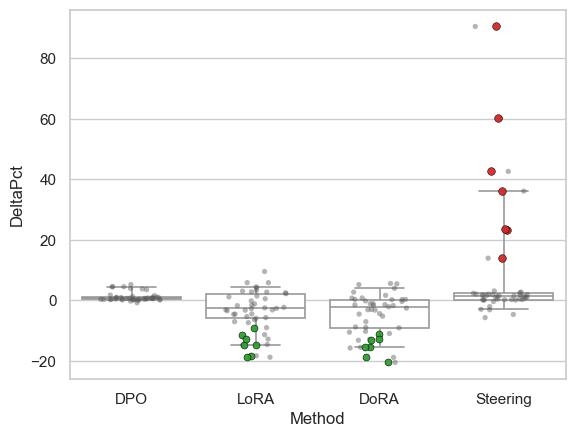

In [15]:
# Base layer: all points in grey
sns.boxplot(
    data=long,
    x="Method",
    y="DeltaPct",
    whis=[5, 95],
    showfliers=False,
    color="white",
    linewidth=1.2,
)

sns.stripplot(
    data=long,
    x="Method",
    y="DeltaPct",
    jitter=0.25,
    size=3.8,
    alpha=0.45,
    color="0.35",
    edgecolor="none",
)

# Highlight: Qwen 0.5B + Steering
mask_qwen05_steer = (long["Model"].str.contains("Qwen2.5-0.5B")) & (
    long["Method"] == "Steering"
)
sns.stripplot(
    data=long[mask_qwen05_steer],
    x="Method",
    y="DeltaPct",
    jitter=0.12,
    size=5.5,
    alpha=0.95,
    color="#d62728",  # red
    edgecolor="black",
    linewidth=0.4,
)

# Highlight: Gemma 1B + PEFT (LoRA/DoRA)
mask_gemma_peft = (long["Model"].str.contains("gemma-3-1b")) & (
    long["Method"].isin(["LoRA", "DoRA"])
)
sns.stripplot(
    data=long[mask_gemma_peft],
    x="Method",
    y="DeltaPct",
    jitter=0.12,
    size=5.0,
    alpha=0.95,
    color="#2ca02c",  # green
    edgecolor="black",
    linewidth=0.4,
)

worst = long.loc[long["DeltaPct"].idxmax()]
ax.annotate(
    f'{worst["Model"].split("/")[-1]}, {worst["Language"]}\n{worst["DeltaPct"]:.1f}%',
    xy=(["DPO", "LoRA", "DoRA", "Steering"].index(worst["Method"]), worst["DeltaPct"]),
    xytext=(15, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=8,
)

Missing values in heatmap at:
[('Qwen 2.5\n7B', 'GRPO')]


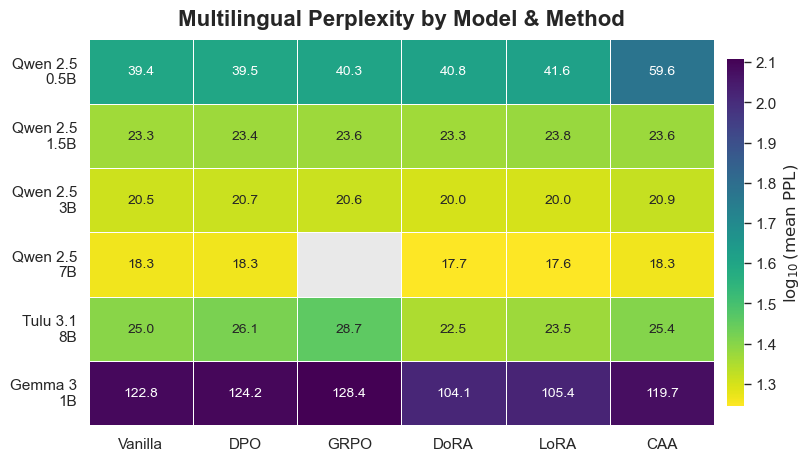

In [30]:
# --- reset any earlier global styling that may be blowing up fonts
plt.rcdefaults()

# paper-friendly defaults (explicit sizes so it’s stable)
sns.set_theme(
    context="paper",
    style="white",
    rc={
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    },
)

# build matrix (mean PPL across languages)
ppl = (
    bar_data_agg.pivot_table(
        index="Model",
        columns="Method",
        values="PPL",
        aggfunc="mean",
    )
    .reindex(index=model_order, columns=methods_to_plot)
)

# Optional: surface missing entries clearly
missing = ppl.isna()
if missing.any().any():
    print("Missing values in heatmap at:")
    print(missing[missing].stack().index.tolist())

# color uses log10 to prevent Gemma dominating the colormap
color_data = np.log10(ppl)

cmap = sns.color_palette("viridis_r", as_cmap=True)
cmap.set_bad(color="#e9e9e9")  # how NaNs look

# choose ONE size:
FIGSIZE = (8, 4.5)  # or (8, 6)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

sns.heatmap(
    color_data,
    ax=ax,
    cmap=cmap,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": r"$\log_{10}(\mathrm{mean\ PPL})$",
        "shrink": 0.9,
        "pad": 0.02,
    },
    # annotate with original (non-log) numbers
    annot=ppl,
    fmt=".1f",
    annot_kws={"fontsize": 10},
)

ax.set_title("Multilingual Perplexity by Model & Method", pad=10)
ax.set_xlabel("")
ax.set_ylabel("")

# keep your existing newline model labels, just make them readable
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.savefig(
    "notebook_plots/ppl_heatmap_v2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

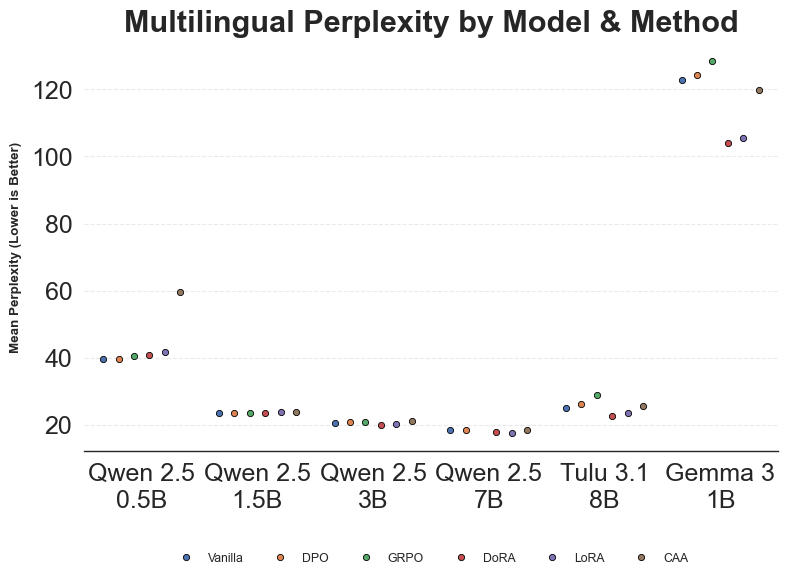

In [41]:
# prep data
df = pd.read_csv("res.csv")
df = df[df['Metrics'] == 'ppl'].copy()

model_map = {
    "Qwen/Qwen2.5-0.5B-Instruct": "Qwen 2.5\n0.5B",
    "Qwen/Qwen2.5-1.5B-Instruct": "Qwen 2.5\n1.5B",
    "Qwen/Qwen2.5-3B-Instruct": "Qwen 2.5\n3B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen 2.5\n7B",
    "allenai/Llama-3.1-Tulu-3.1-8B": "Tulu 3.1\n8B",
    "google/gemma-3-1b-it": "Gemma 3\n1B",
}

df['Model'] = df['Model'].map(model_map)
df['Language'] = df['Dataset'].str.replace('PPL ', '')

model_order = [
    "Qwen 2.5\n0.5B",
    "Qwen 2.5\n1.5B",
    "Qwen 2.5\n3B",
    "Qwen 2.5\n7B",
    "Tulu 3.1\n8B",
    "Gemma 3\n1B",
]

methods_to_plot = ['Vanilla', 'DPO', 'GRPO', 'DoRA', 'LoRA', 'CAA']

bar_data = df.melt(
    id_vars=['Model'], 
    value_vars=methods_to_plot, 
    var_name='Method', 
    value_name='PPL'
)

bar_data_agg = (
    bar_data.groupby(["Model", "Method"])["PPL"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(8, 6))  # ~single-column width

classic_palette = sns.color_palette(n_colors=len(methods_to_plot))

sns.stripplot(
    data=bar_data_agg,
    x="Model",
    y="PPL",
    hue="Method",
    order=model_order,
    hue_order=methods_to_plot,
    dodge=True,
    jitter=False,
    size=4.5,
    linewidth=0.6,
    edgecolor="black",
    palette=classic_palette,
    ax=ax,
)

# Helps a lot when one model (Gemma) is way higher than the others:
# ax.set_yscale("log")  # comment out if you want linear scale

sns.despine(left=True)
ax.set_ylabel("Mean Perplexity (Lower is Better)", fontweight="bold", labelpad=6)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_title("Multilingual Perplexity by Model & Method", fontweight="bold", pad=8)

# Two-row legend fits better in a narrow column
sns.move_legend(
    ax,
    "upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=6,
    frameon=False,
    title=None,
)

plt.tight_layout()
plt.savefig("notebook_plots/ppl_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()